### Load all the Powder Patch data from MesoWest - Synoptic Weather API

Notebook contents 
* loading all the data that I could download from Powder Patch (starting 2014 earliest) on the MesoWest (not Mesonet) Synoptic Weather API

created by Cassie Lumbrazo\
last updated: June 2025\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

In [2]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

In [3]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

In [4]:
filename = '/home/cassie/data/fishcreek/mesowest/rawdata/PPSA2_Synoptic_everything_utc_time_remove_header.csv'
df_mesowest= pd.read_csv(filename, sep = ",")
df_mesowest

/tmp/ipykernel_3357678/17159684.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mesowest= pd.read_csv(filename, sep = ",")


,Station_ID,Date_Time,air_temp_set_1,relative_humidity_set_1,snow_depth_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,heat_index_set_1d,dew_point_temperature_set_1d
0,NaN,NaN,Celsius,%,Millimeters,Millimeters,volts,Millimeters,Celsius,Celsius
1,PPSA2,2014-01-09T15:00:00Z,-1.43,91.9,NaN,NaN,NaN,NaN,NaN,-2.59
2,PPSA2,2014-01-09T15:30:00Z,-1.38,92.0,NaN,NaN,NaN,NaN,NaN,-2.53
3,PPSA2,2014-01-09T16:00:00Z,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
4,PPSA2,2014-01-09T16:30:00Z,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
...,...,...,...,...,...,...,...,...,...,...
82029,PPSA2,2025-06-27T08:00:00Z,8.31,94.0,3.81,2440.94,13.26,45.72,NaN,7.39
82030,PPSA2,2025-06-27T09:00:00Z,8.43,94.3,0.0,2440.94,13.26,48.26,NaN,7.56
82031,PPSA2,2025-06-27T10:00:00Z,8.61,93.3,0.0,2441.956,13.26,45.72,NaN,7.58
82032,PPSA2,2025-06-27T11:00:00Z,8.56,93.3,0.0,2441.956,13.27,45.72,NaN,7.53


In [5]:
# Convert 'Date_Time' to datetime, skipping the first row (units row)
df_mesowest = df_mesowest.iloc[1:].copy()
df_mesowest['Date_Time'] = pd.to_datetime(df_mesowest['Date_Time'], utc=True)
# set datetime as the index
df_mesowest.set_index('Date_Time', inplace=True)
df_mesowest.head()

,Station_ID,air_temp_set_1,relative_humidity_set_1,snow_depth_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,heat_index_set_1d,dew_point_temperature_set_1d
Date_Time,,,,,,,,,
2014-01-09 15:00:00+00:00,PPSA2,-1.43,91.9,NaN,NaN,NaN,NaN,NaN,-2.59
2014-01-09 15:30:00+00:00,PPSA2,-1.38,92.0,NaN,NaN,NaN,NaN,NaN,-2.53
2014-01-09 16:00:00+00:00,PPSA2,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 16:30:00+00:00,PPSA2,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 17:00:00+00:00,PPSA2,-1.38,91.8,NaN,NaN,NaN,NaN,NaN,-2.56


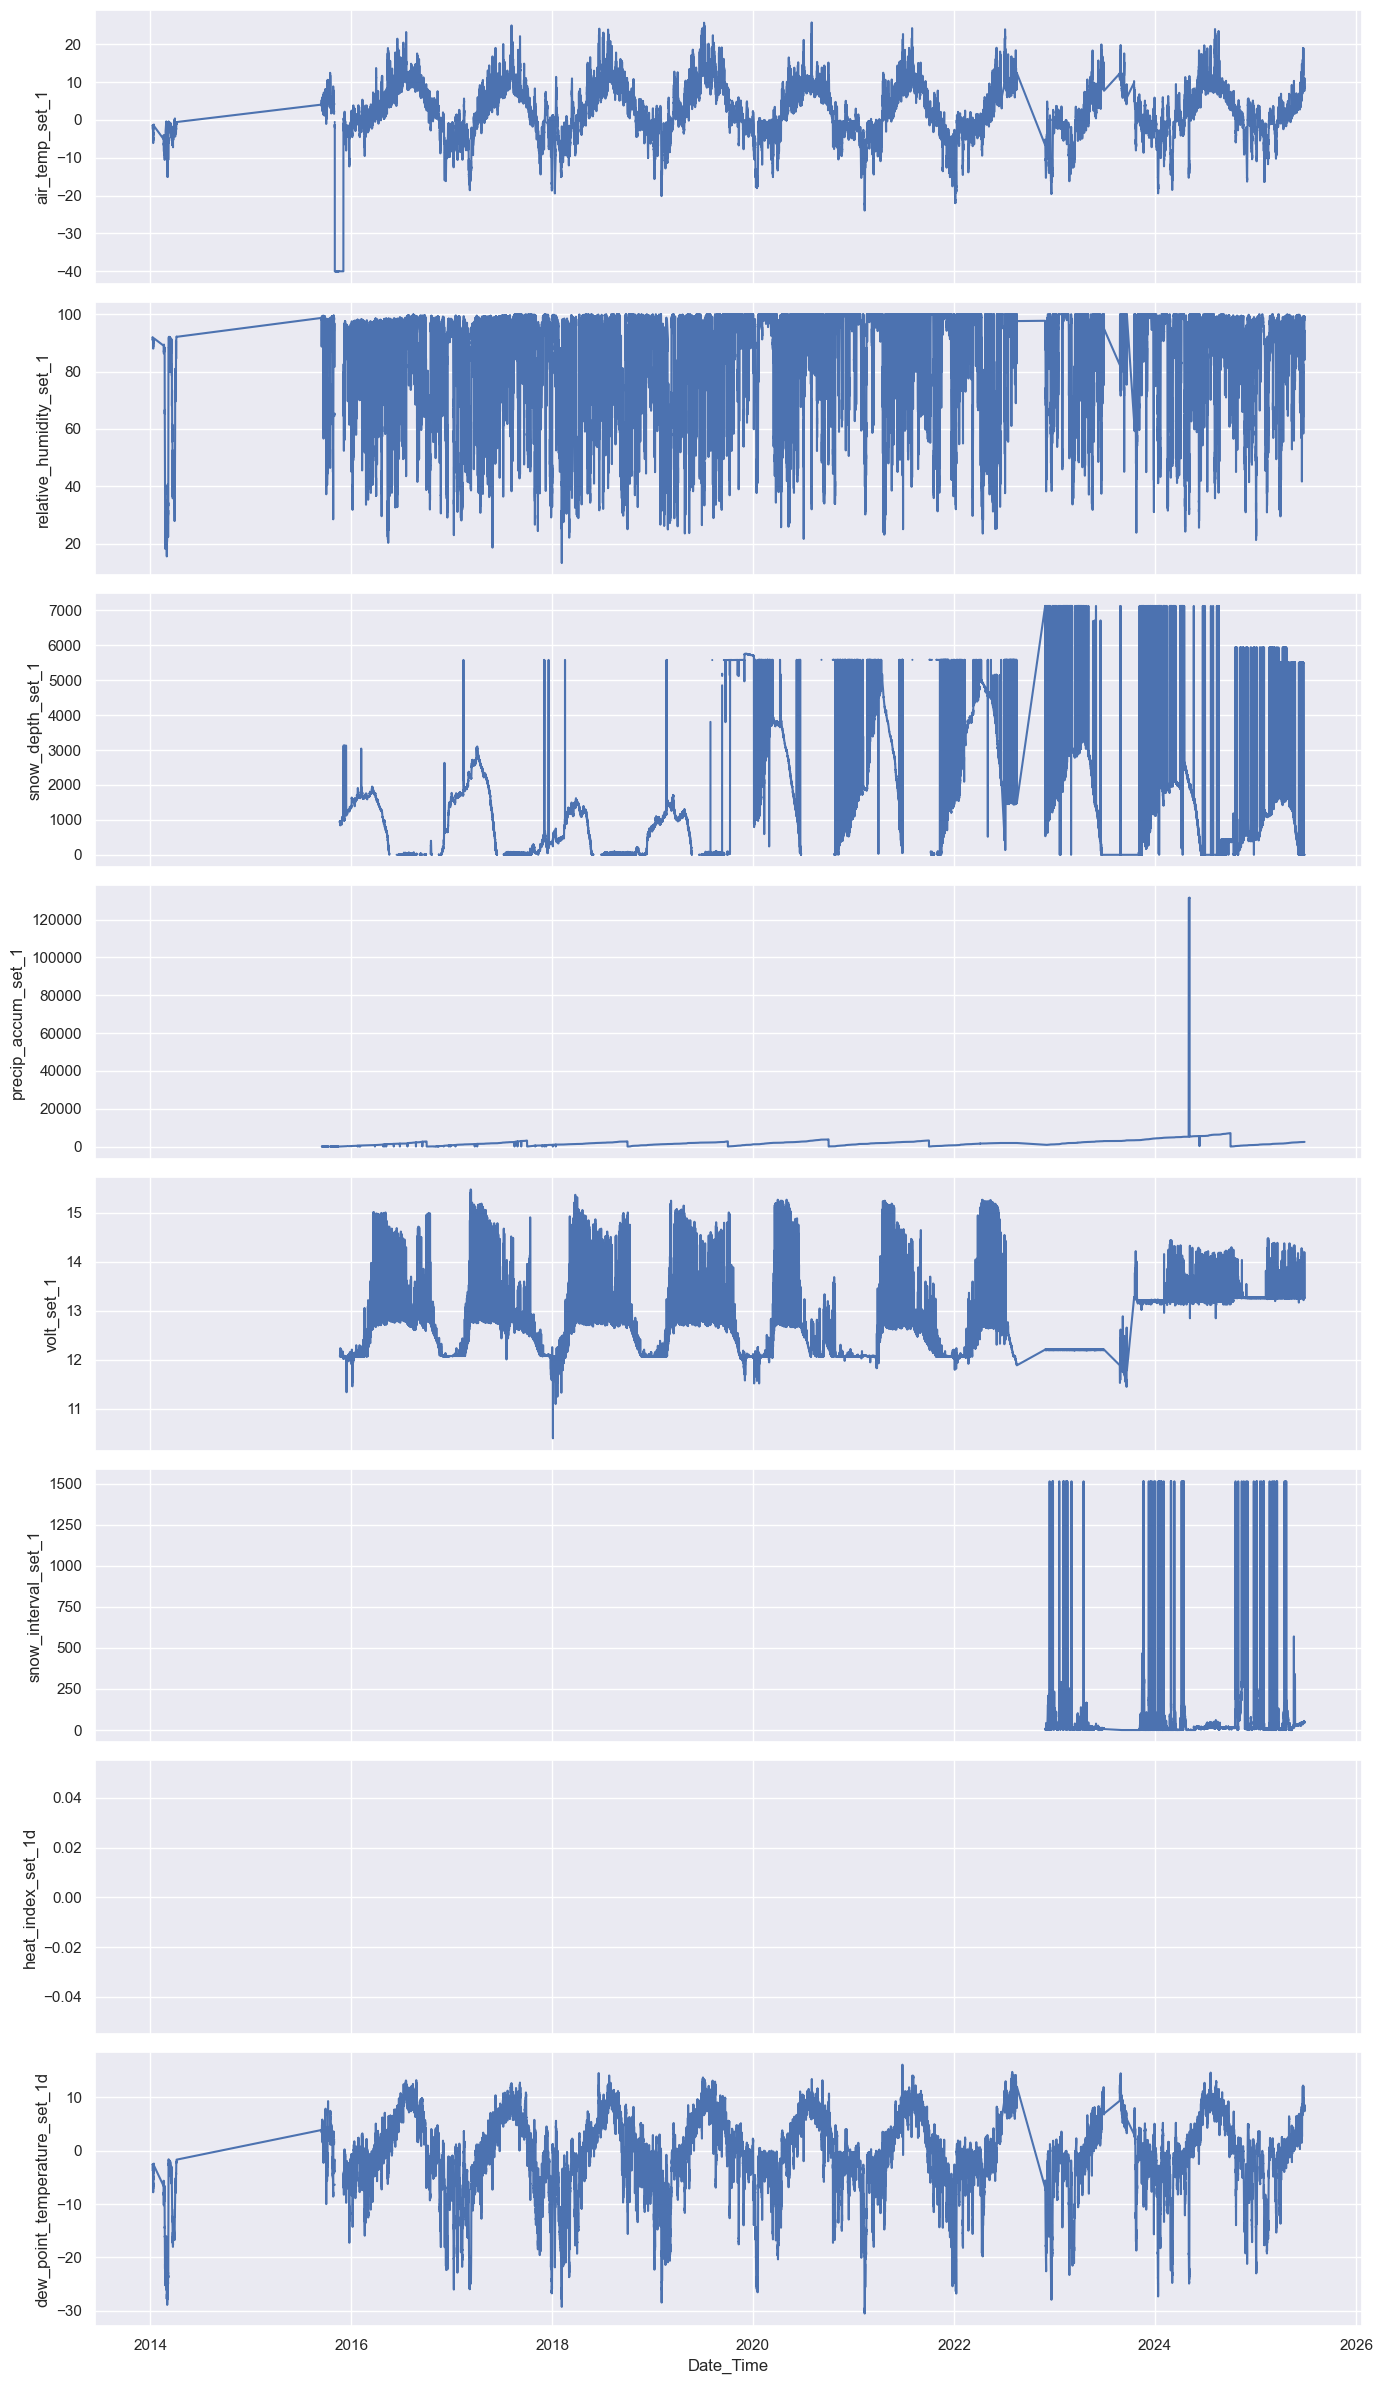

In [6]:
# Convert all other columns (except Station_ID) to numeric, coerce errors
for col in df_mesowest.columns:
    if col not in ['Station_ID', 'Date_Time']:
        df_mesowest[col] = pd.to_numeric(df_mesowest[col], errors='coerce')

# Plot all variables as timeseries in subplots
variables = [col for col in df_mesowest.columns if col not in ['Station_ID', 'Date_Time']]
n_vars = len(variables)

fig, axes = plt.subplots(n_vars, 1, figsize=(14, 3 * n_vars), sharex=True)
if n_vars == 1:
    axes = [axes]

for ax, var in zip(axes, variables):
    ax.plot(df_mesowest[var])
    ax.set_ylabel(var)
    ax.grid(True)

axes[-1].set_xlabel('Date_Time')
plt.tight_layout()
plt.show()

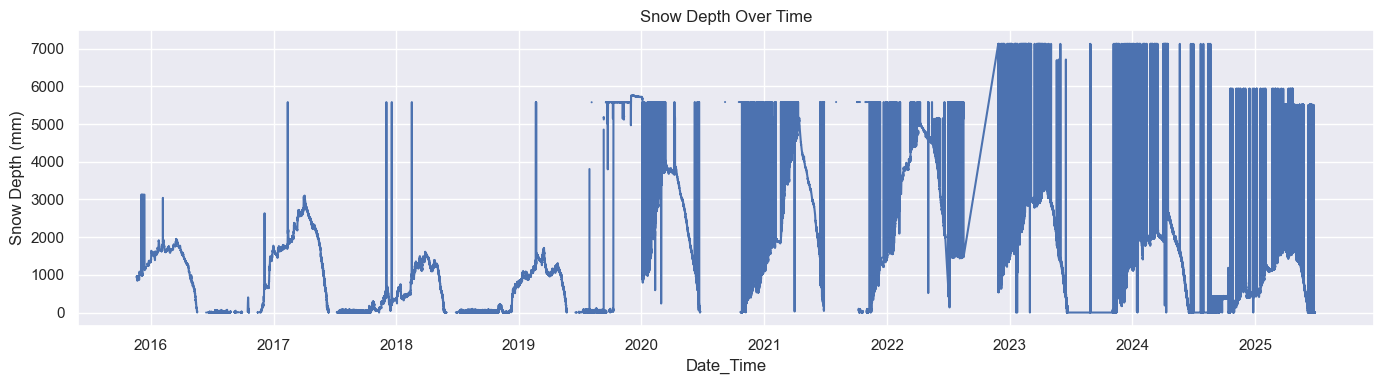

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(df_mesowest['snow_depth_set_1'])
plt.xlabel('Date_Time')
plt.ylabel('Snow Depth (mm)')
plt.title('Snow Depth Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

Now, download the Mesonet data as well to plot this with the Mesowest data...

In [8]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_mesonet = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_mesonet by it 
df_mesonet['datetime'] = pd.to_datetime(df_mesonet['utc_valid'], utc=True)
df_mesonet = df_mesonet.set_index('datetime')
df_mesonet.head()

df_mesonet.head()

,station,utc_valid,PCIRZZ,PCIRZZZ,RNIRZZ,SDIRZZ,SDIRZZZ,TAIRZZ,TAIRZZZ,UDIRZZ,UHIRZZZ,UPIRZZ,UPIRZZZ,USIRZZ,USIRZZZ,VBIRZZ,VBIRZZZ,XRIRZZ,XRIRZZZ
datetime,,,,,,,,,,,,,,,,,,,
2010-12-15 22:00:00+00:00,PPSA2,2010-12-15 22:00:00,NaN,NaN,0.0,35.0,NaN,18.0,NaN,170.0,NaN,NaN,NaN,1.790,NaN,NaN,NaN,80.20,NaN
2011-01-09 04:15:00+00:00,PPSA2,2011-01-09 04:15:00,NaN,NaN,NaN,55.0,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.00,NaN
2011-05-21 03:45:00+00:00,PPSA2,2011-05-21 03:45:00,NaN,NaN,0.0,90.0,NaN,50.3,NaN,102.0,NaN,NaN,NaN,0.631,NaN,NaN,NaN,73.79,NaN
2011-05-21 04:15:00+00:00,PPSA2,2011-05-21 04:15:00,NaN,NaN,0.0,90.0,NaN,45.7,NaN,103.0,NaN,NaN,NaN,1.060,NaN,NaN,NaN,84.80,NaN
2011-05-21 04:45:00+00:00,PPSA2,2011-05-21 04:45:00,NaN,NaN,0.0,90.0,NaN,44.5,NaN,110.0,NaN,NaN,NaN,1.270,NaN,NaN,NaN,87.10,NaN


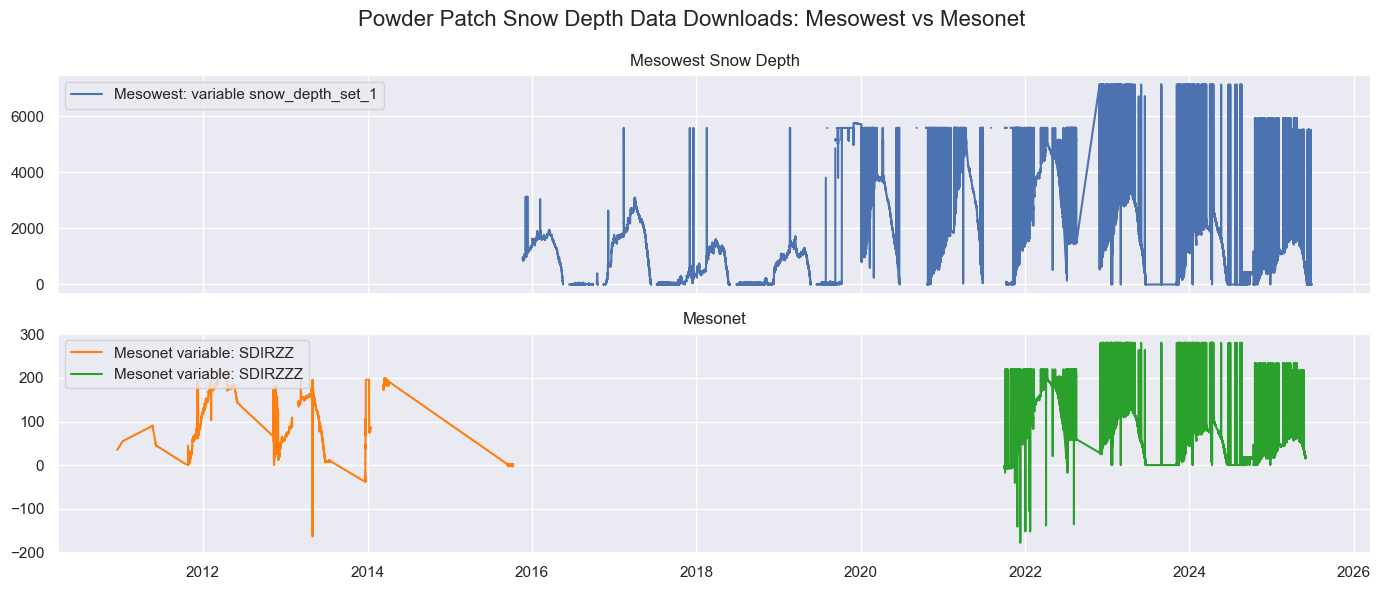

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

plt.suptitle('Powder Patch Snow Depth Data Downloads: Mesowest vs Mesonet', fontsize=16)
# Plot Mesowest snow depth
axes[0].plot(df_mesowest.index, df_mesowest['snow_depth_set_1'], label='Mesowest: variable snow_depth_set_1')
axes[0].set_title('Mesowest Snow Depth')
axes[0].legend(loc='upper left')
axes[0].grid(True)

# Plot Mesonet SDIRZZ
axes[1].plot(df_mesonet.index, df_mesonet['SDIRZZ'], label='Mesonet variable: SDIRZZ', color='tab:orange')
axes[1].plot(df_mesonet.index, df_mesonet['SDIRZZZ'], label='Mesonet variable: SDIRZZZ', color='tab:green')

axes[1].set_title('Mesonet')
axes[1].legend(loc='upper left')
axes[1].grid(True)

# # Plot Mesonet SDIRZZZ
# axes[2].plot(df_mesonet.index, df_mesonet['SDIRZZZ'], label='Mesonet SDIRZZZ', color='tab:green')
# axes[2].set_ylabel('Snow Depth (cm)')
# axes[2].set_title('Mesonet SDIRZZZ')
# axes[2].legend()
# axes[2].grid(True)

axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

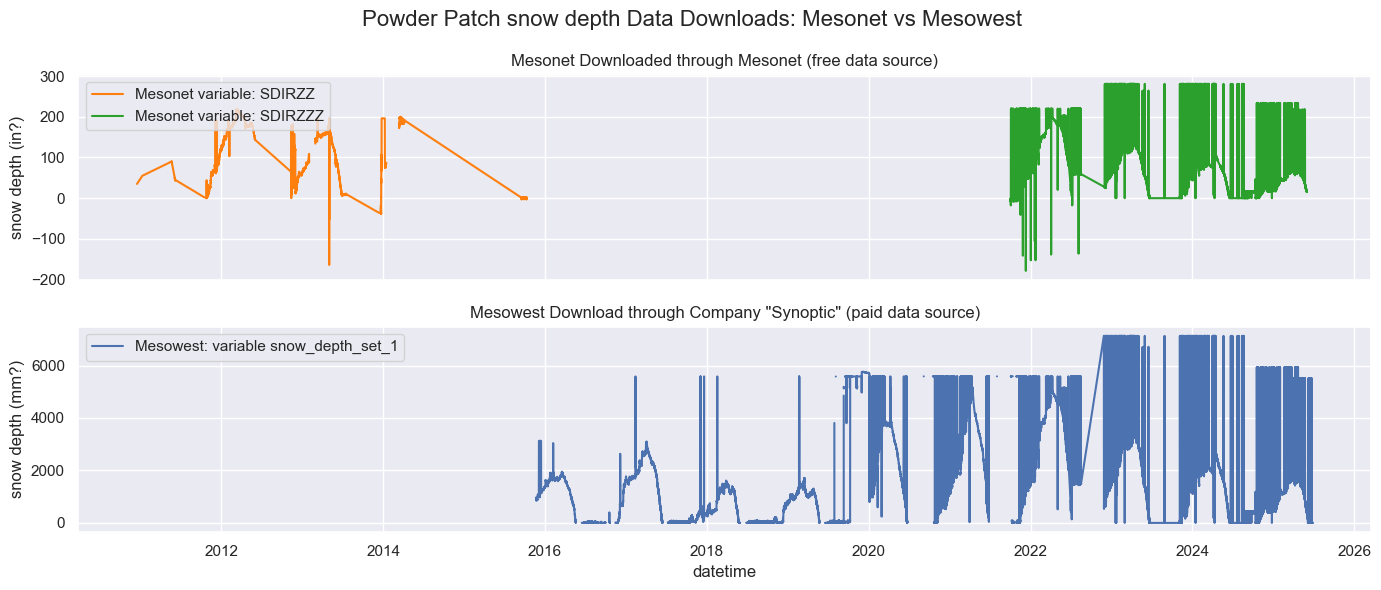

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

plt.suptitle('Powder Patch snow depth Data Downloads: Mesonet vs Mesowest', fontsize=16)

# Plot Mesonet 
axes[0].plot(df_mesonet.index, df_mesonet['SDIRZZ'], label='Mesonet variable: SDIRZZ', color='tab:orange')
axes[0].plot(df_mesonet.index, df_mesonet['SDIRZZZ'], label='Mesonet variable: SDIRZZZ', color='tab:green')

axes[0].set_ylabel('snow depth (in?)')
axes[0].set_title('Mesonet Downloaded through Mesonet (free data source)')
axes[0].legend(loc='upper left')
axes[0].grid(True)

# Plot Mesowest
axes[1].plot(df_mesowest.index, df_mesowest['snow_depth_set_1'], label='Mesowest: variable snow_depth_set_1')
axes[1].set_ylabel('snow depth (mm?)')
axes[1].set_title('Mesowest Download through Company "Synoptic" (paid data source)')
axes[1].legend(loc='upper left')
axes[1].grid(True)

axes[1].set_xlabel('datetime')
plt.tight_layout()
plt.show()

In [11]:
df_mesowest

,Station_ID,air_temp_set_1,relative_humidity_set_1,snow_depth_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,heat_index_set_1d,dew_point_temperature_set_1d
Date_Time,,,,,,,,,
2014-01-09 15:00:00+00:00,PPSA2,-1.43,91.9,NaN,NaN,NaN,NaN,NaN,-2.59
2014-01-09 15:30:00+00:00,PPSA2,-1.38,92.0,NaN,NaN,NaN,NaN,NaN,-2.53
2014-01-09 16:00:00+00:00,PPSA2,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 16:30:00+00:00,PPSA2,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 17:00:00+00:00,PPSA2,-1.38,91.8,NaN,NaN,NaN,NaN,NaN,-2.56
...,...,...,...,...,...,...,...,...,...
2025-06-27 08:00:00+00:00,PPSA2,8.31,94.0,3.81,2440.940,13.26,45.72,NaN,7.39
2025-06-27 09:00:00+00:00,PPSA2,8.43,94.3,0.00,2440.940,13.26,48.26,NaN,7.56
2025-06-27 10:00:00+00:00,PPSA2,8.61,93.3,0.00,2441.956,13.26,45.72,NaN,7.58


In [12]:
# Create a tidy dataframe with datetime as index and snow depth variables as columns

# Prepare Mesowest snow depth (convert mm to cm)
mesowest_sd = df_mesowest[['snow_depth_set_1']].copy()
# mesowest_sd = mesowest_sd.dropna(subset=['snow_depth_set_1']) # removed all the Date_Time so we don't need this code anymore...
# mesowest_sd['Date_Time'] = pd.to_datetime(mesowest_sd['Date_Time'])
# mesowest_sd = mesowest_sd.set_index('Date_Time')
mesowest_sd['snow_depth_mesowest_cm'] = mesowest_sd['snow_depth_set_1'] / 10.0
mesowest_sd = mesowest_sd[['snow_depth_mesowest_cm']]

# Prepare Mesonet snow depths (already in cm)
mesonet_sd = df_mesonet[['SDIRZZ', 'SDIRZZZ']].copy()
mesonet_sd = mesonet_sd.rename(columns={'SDIRZZ': 'snow_depth_mesonet_cm', 'SDIRZZZ': 'snow_depth_mesonet2_cm'})

# Join on datetime index (outer join to keep all timestamps)
df_snow = mesowest_sd.join(mesonet_sd, how='outer')

# Remove negative snow depths
for col in df_snow.columns:
    df_snow.loc[df_snow[col] < 0, col] = np.nan

df_snow.head()

,snow_depth_mesowest_cm,snow_depth_mesonet_cm,snow_depth_mesonet2_cm
2010-12-15 22:00:00+00:00,NaN,35.0,NaN
2011-01-09 04:15:00+00:00,NaN,55.0,NaN
2011-05-21 03:45:00+00:00,NaN,90.0,NaN
2011-05-21 04:15:00+00:00,NaN,90.0,NaN
2011-05-21 04:45:00+00:00,NaN,90.0,NaN


In [13]:
# create a new tidy dataframe with just the snow depth data from both sources for easier comparison
df_mesonet_snow = df_mesonet[['SDIRZZ', 'SDIRZZZ']].copy()
df_mesonet_snow = df_mesonet_snow.rename(columns={'SDIRZZ': 'mesonet_SDIRZZ', 'SDIRZZZ': 'mesonet_SDIRZZZ'})
df_mesonet_snow.head()

,mesonet_SDIRZZ,mesonet_SDIRZZZ
datetime,,
2010-12-15 22:00:00+00:00,35.0,NaN
2011-01-09 04:15:00+00:00,55.0,NaN
2011-05-21 03:45:00+00:00,90.0,NaN
2011-05-21 04:15:00+00:00,90.0,NaN
2011-05-21 04:45:00+00:00,90.0,NaN


In [14]:
# now create a df_mesowest_snow
df_mesowest_snow = df_mesowest[['snow_depth_set_1']].copy()
df_mesowest_snow = df_mesowest_snow.rename(columns={'snow_depth_set_1': 'mesowest_snow_depth_set_1'})
df_mesowest_snow.head()

,mesowest_snow_depth_set_1
Date_Time,
2014-01-09 15:00:00+00:00,NaN
2014-01-09 15:30:00+00:00,NaN
2014-01-09 16:00:00+00:00,NaN
2014-01-09 16:30:00+00:00,NaN
2014-01-09 17:00:00+00:00,NaN


In [15]:
# combine the two dataframes on their datetime index
df_snow = pd.concat([df_mesonet_snow, df_mesowest_snow], axis=0)
df_snow.head()

,mesonet_SDIRZZ,mesonet_SDIRZZZ,mesowest_snow_depth_set_1
2010-12-15 22:00:00+00:00,35.0,NaN,NaN
2011-01-09 04:15:00+00:00,55.0,NaN,NaN
2011-05-21 03:45:00+00:00,90.0,NaN,NaN
2011-05-21 04:15:00+00:00,90.0,NaN,NaN
2011-05-21 04:45:00+00:00,90.0,NaN,NaN


In [16]:
# convert mesonet_SDIRZZ and mesonet_SDIRZZZ from inches to cm 
df_snow['mesonet_SDIRZZ'] = df_snow['mesonet_SDIRZZ'] * 2.54  # inches to cm
df_snow['mesonet_SDIRZZZ'] = df_snow['mesonet_SDIRZZZ'] * 2.54  # inches to cm

# convert mesowest snow_depth_set_1 from mm to cm
df_snow['mesowest_snow_depth_set_1'] = df_snow['mesowest_snow_depth_set_1'] / 10.0  # mm to cm
df_snow.head()

,mesonet_SDIRZZ,mesonet_SDIRZZZ,mesowest_snow_depth_set_1
2010-12-15 22:00:00+00:00,88.9,NaN,NaN
2011-01-09 04:15:00+00:00,139.7,NaN,NaN
2011-05-21 03:45:00+00:00,228.6,NaN,NaN
2011-05-21 04:15:00+00:00,228.6,NaN,NaN
2011-05-21 04:45:00+00:00,228.6,NaN,NaN


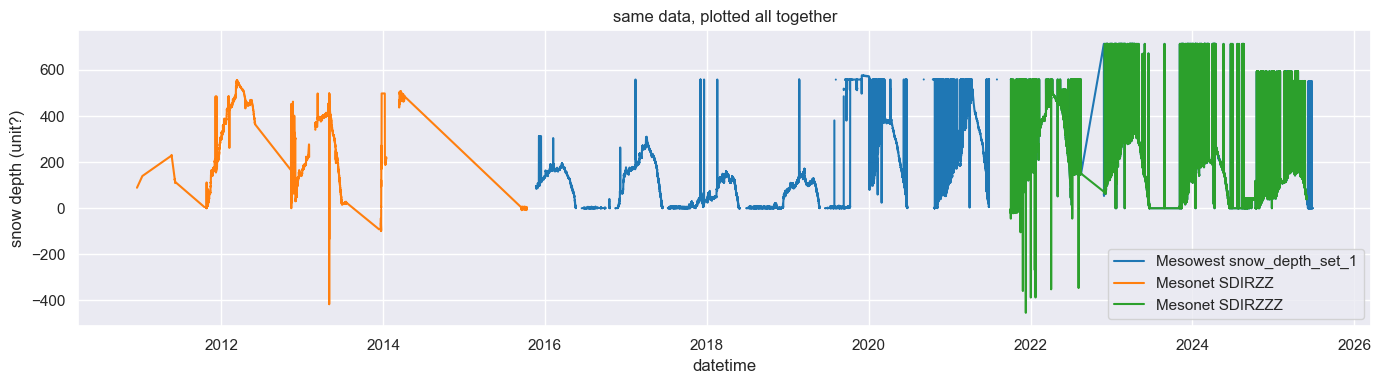

In [17]:
# now plot all three variables on the same plot with different colors 
plt.figure(figsize=(14, 4))
plt.plot(df_snow.index, df_snow['mesowest_snow_depth_set_1'], label='Mesowest snow_depth_set_1', color='tab:blue')
plt.plot(df_snow.index, df_snow['mesonet_SDIRZZ'], label='Mesonet SDIRZZ', color='tab:orange')
plt.plot(df_snow.index, df_snow['mesonet_SDIRZZZ'], label='Mesonet SDIRZZZ', color='tab:green')
plt.xlabel('datetime')
plt.ylabel('snow depth (unit?)')
plt.title('same data, plotted all together')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

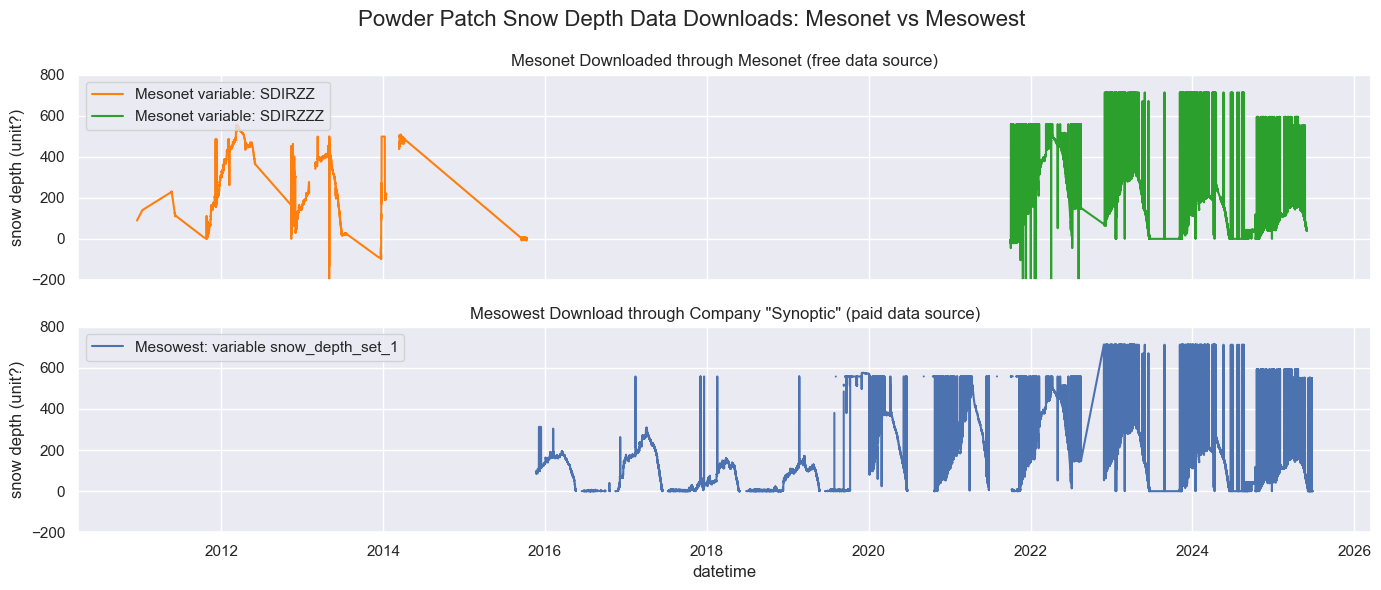

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

plt.suptitle('Powder Patch Snow Depth Data Downloads: Mesonet vs Mesowest', fontsize=16)

# Plot Mesonet 
axes[0].plot(df_snow.index, df_snow['mesonet_SDIRZZ'], label='Mesonet variable: SDIRZZ', color='tab:orange')
axes[0].plot(df_snow.index, df_snow['mesonet_SDIRZZZ'], label='Mesonet variable: SDIRZZZ', color='tab:green')

axes[0].set_ylabel('snow depth (unit?)')
axes[0].set_title('Mesonet Downloaded through Mesonet (free data source)')
axes[0].legend(loc='upper left')
axes[0].grid(True)

# Plot Mesowest
axes[1].plot(df_snow.index, df_snow['mesowest_snow_depth_set_1'], label='Mesowest: variable snow_depth_set_1')
axes[1].set_ylabel('snow depth (unit?)')
axes[1].set_title('Mesowest Download through Company "Synoptic" (paid data source)')
axes[1].legend(loc='upper left')
axes[1].grid(True)

axes[1].set_xlabel('datetime')

# plot the y-axis from 0 to 100 cm for both plots for easier comparison
axes[0].set_ylim(-200, 800)
axes[1].set_ylim(-200, 800)

plt.tight_layout()
plt.show()

very light cleaning to start..

In [32]:
df_snow_clean = df_snow.copy()

for col in ['mesonet_SDIRZZ', 'mesonet_SDIRZZZ', 'mesowest_snow_depth_set_1']:
    if col in df_snow_clean.columns:
        df_snow_clean[col] = df_snow_clean[col].where(
            (df_snow_clean[col] >= 0) & (df_snow_clean[col] <= 450)
        )
df_snow_clean.head()

,mesonet_SDIRZZ,mesonet_SDIRZZZ,mesowest_snow_depth_set_1
2010-12-15 22:00:00+00:00,88.9,NaN,NaN
2011-01-09 04:15:00+00:00,139.7,NaN,NaN
2011-05-21 03:45:00+00:00,228.6,NaN,NaN
2011-05-21 04:15:00+00:00,228.6,NaN,NaN
2011-05-21 04:45:00+00:00,228.6,NaN,NaN


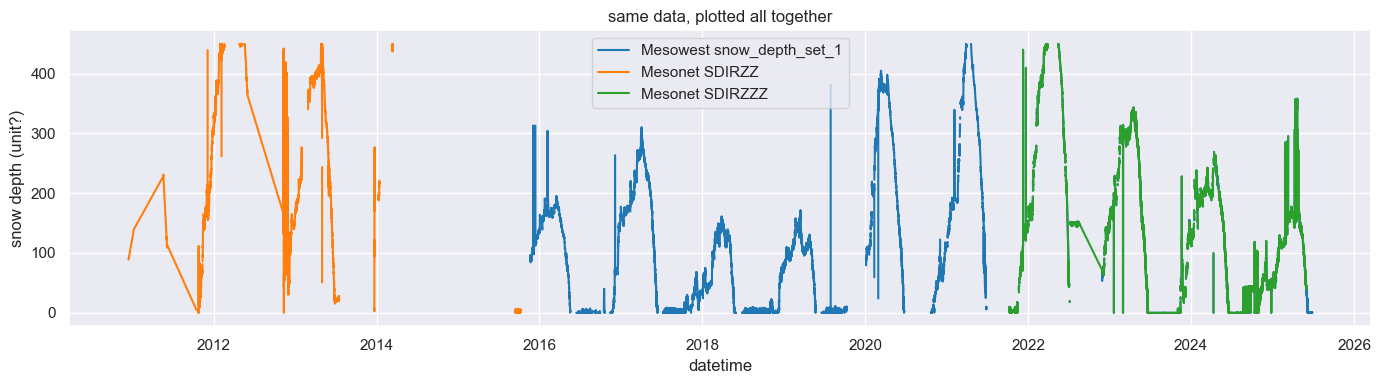

In [20]:
# now plot all three variables on the same plot with different colors 
plt.figure(figsize=(14, 4))
plt.plot(df_snow_clean.index, df_snow_clean['mesowest_snow_depth_set_1'], label='Mesowest snow_depth_set_1', color='tab:blue')
plt.plot(df_snow_clean.index, df_snow_clean['mesonet_SDIRZZ'], label='Mesonet SDIRZZ', color='tab:orange')
plt.plot(df_snow_clean.index, df_snow_clean['mesonet_SDIRZZZ'], label='Mesonet SDIRZZZ', color='tab:green')
plt.xlabel('datetime')
plt.ylabel('snow depth (unit?)')
plt.title('same data, plotted all together')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
def remove_spikes(series, window=5, threshold=30, rate_limit=50):
    """
    Remove spikes/drops in snow depth based on local median and rate of change.
    Args:
        series: pandas Series (snow depth in cm)
        window: rolling window size
        threshold: max allowed deviation from rolling median (in cm)
        rate_limit: max allowed delta between steps (in cm)
    Returns:
        Cleaned pandas Series
    """
    series = series.copy()
    rolling_median = series.rolling(window=window, center=True, min_periods=1).median()
    
    # Detect spike-like deviations from median
    spike_mask = (series - rolling_median).abs() > threshold
    
    # Detect unrealistic changes between consecutive time steps
    diff = series.diff().abs()
    rate_mask = diff > rate_limit

    # Combine all bad data flags
    bad_mask = spike_mask | rate_mask
    series[bad_mask] = np.nan
    return series

# Apply the spike removal function to each snow depth column
df_snow_qc = df_snow_clean.copy()
for col in ['mesonet_SDIRZZ', 'mesonet_SDIRZZZ', 'mesowest_snow_depth_set_1']:
    if col in df_snow_qc.columns:
        cleaned = remove_spikes(df_snow_qc[col], window=5, threshold=50, rate_limit=10)
        # df_snow_qc[col] = cleaned.interpolate(limit=3, limit_direction='both')  # Optional

df_snow_qc.head()    

,mesonet_SDIRZZ,mesonet_SDIRZZZ,mesowest_snow_depth_set_1
2010-12-15 22:00:00+00:00,88.9,NaN,NaN
2011-01-09 04:15:00+00:00,139.7,NaN,NaN
2011-05-21 03:45:00+00:00,228.6,NaN,NaN
2011-05-21 04:15:00+00:00,228.6,NaN,NaN
2011-05-21 04:45:00+00:00,228.6,NaN,NaN


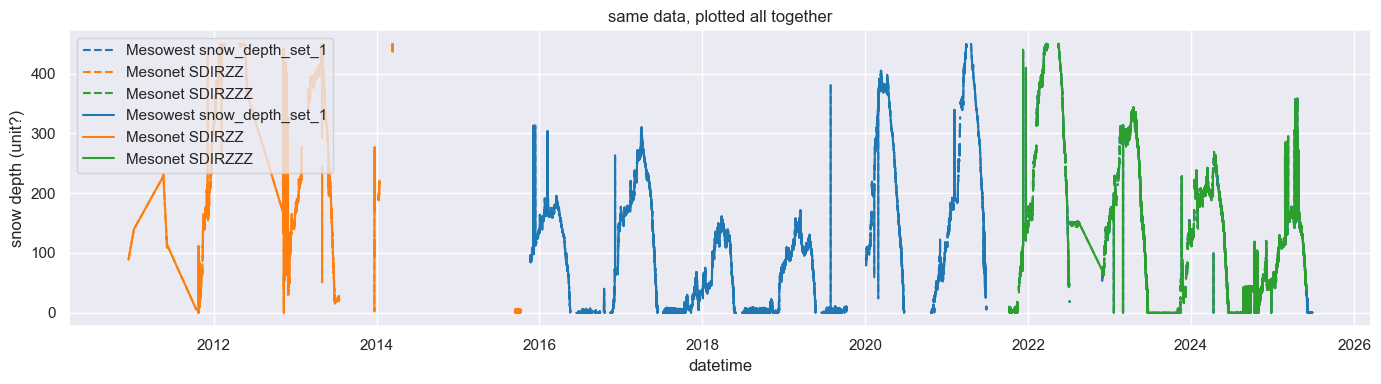

In [22]:
# now plot all three variables on the same plot with different colors 
plt.figure(figsize=(14, 4))
plt.plot(df_snow_clean.index, df_snow_clean['mesowest_snow_depth_set_1'], label='Mesowest snow_depth_set_1', color='tab:blue', linestyle='--')
plt.plot(df_snow_clean.index, df_snow_clean['mesonet_SDIRZZ'], label='Mesonet SDIRZZ', color='tab:orange', linestyle='--')
plt.plot(df_snow_clean.index, df_snow_clean['mesonet_SDIRZZZ'], label='Mesonet SDIRZZZ', color='tab:green', linestyle='--')

plt.plot(df_snow_qc.index, df_snow_qc['mesowest_snow_depth_set_1'], label='Mesowest snow_depth_set_1', color='tab:blue')
plt.plot(df_snow_qc.index, df_snow_qc['mesonet_SDIRZZ'], label='Mesonet SDIRZZ', color='tab:orange')
plt.plot(df_snow_qc.index, df_snow_qc['mesonet_SDIRZZZ'], label='Mesonet SDIRZZZ', color='tab:green')


plt.xlabel('datetime')
plt.ylabel('snow depth (unit?)')
plt.title('same data, plotted all together')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Smoothing with LOESS (or LOWESS) 
A good choice for smoothing nonlinear trends in snow depth while preserving local structure. It's especially useful if your data is seasonal, noisy, and has irregular ups/downs.


In [26]:
import statsmodels.api as sm

In [27]:
df_snow_clean

,mesonet_SDIRZZ,mesonet_SDIRZZZ,mesowest_snow_depth_set_1
2010-12-15 22:00:00+00:00,88.9,NaN,NaN
2011-01-09 04:15:00+00:00,139.7,NaN,NaN
2011-05-21 03:45:00+00:00,228.6,NaN,NaN
2011-05-21 04:15:00+00:00,228.6,NaN,NaN
2011-05-21 04:45:00+00:00,228.6,NaN,NaN
...,...,...,...
2025-06-27 08:00:00+00:00,NaN,NaN,0.381
2025-06-27 09:00:00+00:00,NaN,NaN,0.000
2025-06-27 10:00:00+00:00,NaN,NaN,0.000
2025-06-27 11:00:00+00:00,NaN,NaN,0.000


In [35]:
#rename the variable names so that's its easier to work with... 
df_snow_clean = df_snow_clean.rename(columns={
    'mesowest_snow_depth_set_1': 'mesowest_sd1',
    'mesonet_SDIRZZ': 'mesonet_sd1',
    'mesonet_SDIRZZZ': 'mesonet_sd2'
})
df_snow_clean.head()

,mesonet_sd1,mesonet_sd2,mesowest_sd1,datetime
2010-12-15 22:00:00+00:00,88.9,NaN,NaN,2010-12-15 22:00:00+00:00
2011-01-09 04:15:00+00:00,139.7,NaN,NaN,2011-01-09 04:15:00+00:00
2011-05-21 03:45:00+00:00,228.6,NaN,NaN,2011-05-21 03:45:00+00:00
2011-05-21 04:15:00+00:00,228.6,NaN,NaN,2011-05-21 04:15:00+00:00
2011-05-21 04:45:00+00:00,228.6,NaN,NaN,2011-05-21 04:45:00+00:00


In [36]:
# fix the datetime in the index to follow a regular format
df_snow_clean.index = pd.to_datetime(df_snow_clean.index, utc=True)

# now make the index a column named "datetime"
df_snow_clean['datetime'] = df_snow_clean.index
# df_snow_clean.reset_index(inplace=True)
df_snow_clean.head()

,mesonet_sd1,mesonet_sd2,mesowest_sd1,datetime
2010-12-15 22:00:00+00:00,88.9,NaN,NaN,2010-12-15 22:00:00+00:00
2011-01-09 04:15:00+00:00,139.7,NaN,NaN,2011-01-09 04:15:00+00:00
2011-05-21 03:45:00+00:00,228.6,NaN,NaN,2011-05-21 03:45:00+00:00
2011-05-21 04:15:00+00:00,228.6,NaN,NaN,2011-05-21 04:15:00+00:00
2011-05-21 04:45:00+00:00,228.6,NaN,NaN,2011-05-21 04:45:00+00:00


That did not do anything... anyway, back to the smoothing 

In [44]:
# frac = 0.1 
# df_snow_clean_smoothed = sm.nonparametric.lowess(df_snow_clean, frac=frac, return_sorted=False)
# df_snow_clean_smoothed

# Set smoothing parameter
frac = 0.02  # Adjust this for more/less smoothing

# Reset index to access 'datetime' as a column
df_snow_clean_smoothed = df_snow_clean.reset_index()

# Apply LOWESS smoothing to all numeric columns
for col in ["mesonet_sd1", "mesonet_sd2", "mesowest_sd1"]:
    df_snow_clean_smoothed[col] = sm.nonparametric.lowess(
        df_snow_clean_smoothed[col], df_snow_clean_smoothed["datetime"], frac=frac, return_sorted=False
    )

# Restore datetime as index
df_snow_clean_smoothed.set_index("datetime", inplace=True)
df_snow_clean_smoothed.head()

,index,mesonet_sd1,mesonet_sd2,mesowest_sd1
datetime,,,,
2010-12-15 22:00:00+00:00,2010-12-15 22:00:00+00:00,-734.019461,NaN,NaN
2011-01-09 04:15:00+00:00,2011-01-09 04:15:00+00:00,-677.148819,NaN,NaN
2011-05-21 03:45:00+00:00,2011-05-21 03:45:00+00:00,-367.753918,NaN,NaN
2011-05-21 04:15:00+00:00,2011-05-21 04:15:00+00:00,-367.705075,NaN,NaN
2011-05-21 04:45:00+00:00,2011-05-21 04:45:00+00:00,-367.656233,NaN,NaN


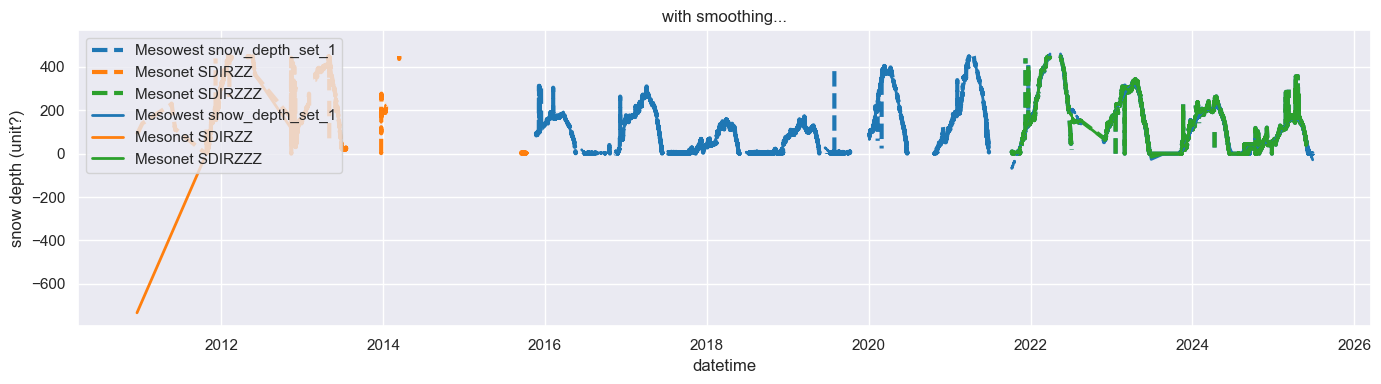

In [45]:
# now plot all three variables on the same plot with different colors 
plt.figure(figsize=(14, 4))
plt.plot(df_snow_clean.index, df_snow_clean['mesowest_sd1'], label='Mesowest snow_depth_set_1', color='tab:blue', linestyle='--', linewidth=3)
plt.plot(df_snow_clean.index, df_snow_clean['mesonet_sd1'], label='Mesonet SDIRZZ', color='tab:orange', linestyle='--',linewidth=3)
plt.plot(df_snow_clean.index, df_snow_clean['mesonet_sd2'], label='Mesonet SDIRZZZ', color='tab:green', linestyle='--',linewidth=3)

plt.plot(df_snow_clean_smoothed.index, df_snow_clean_smoothed['mesowest_sd1'], label='Mesowest snow_depth_set_1', color='tab:blue',linewidth=2)
plt.plot(df_snow_clean_smoothed.index, df_snow_clean_smoothed['mesonet_sd1'], label='Mesonet SDIRZZ', color='tab:orange',linewidth=2)
plt.plot(df_snow_clean_smoothed.index, df_snow_clean_smoothed['mesonet_sd2'], label='Mesonet SDIRZZZ', color='tab:green',linewidth=2)


plt.xlabel('datetime')
plt.ylabel('snow depth (unit?)')
plt.title('with smoothing...')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

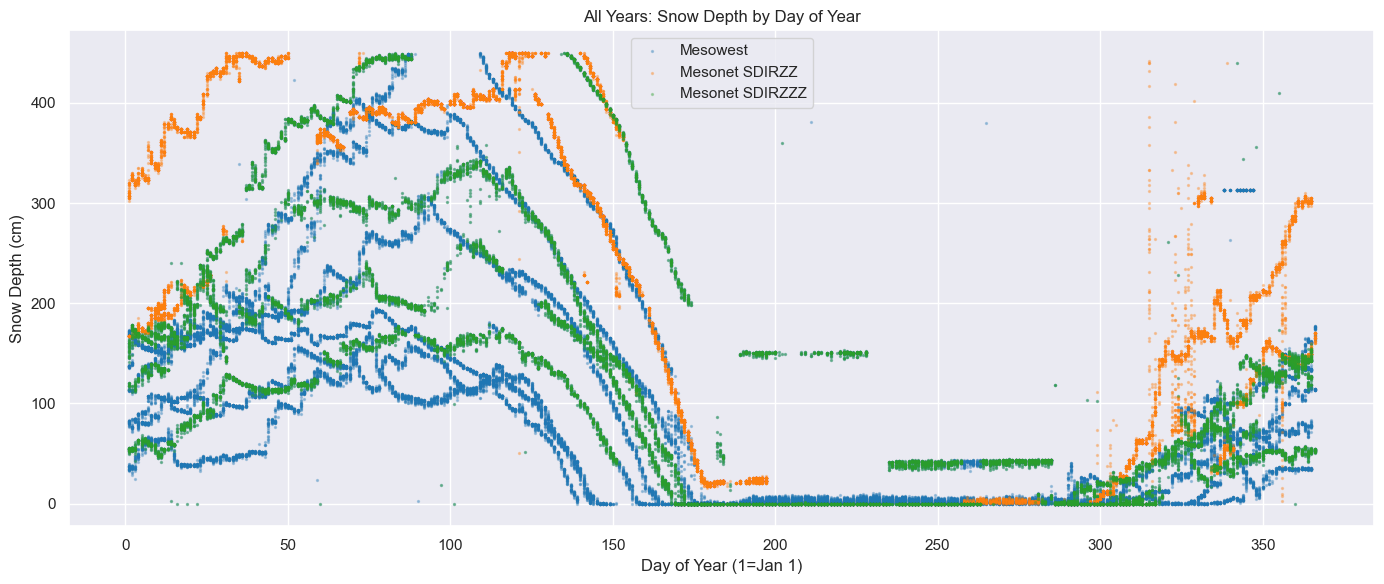

In [ ]:
# Plot all snow depth timeseries by day of year (DOY), ignoring year

plt.figure(figsize=(14, 6))

for col, label, color in [
    ('mesowest_sd1', 'Mesowest', 'tab:blue'),
    ('mesonet_sd1', 'Mesonet SDIRZZ', 'tab:orange'),
    ('mesonet_sd2', 'Mesonet SDIRZZZ', 'tab:green')
]:
    if col in df_snow_clean.columns:
        # Drop NaN for plotting
        series = df_snow_clean[col].dropna()
        # Day of year (1-366)
        doy = series.index.dayofyear
        plt.scatter(doy, series, s=2, alpha=0.3, label=label, color=color)

plt.xlabel('Day of Year (1=Jan 1)')
plt.ylabel('Snow Depth (cm)')
plt.title('All Years: Snow Depth by Day of Year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
df_snow_clean

,mesonet_sd1,mesonet_sd2,mesowest_sd1,datetime
2010-12-15 22:00:00+00:00,88.9,NaN,NaN,2010-12-15 22:00:00+00:00
2011-01-09 04:15:00+00:00,139.7,NaN,NaN,2011-01-09 04:15:00+00:00
2011-05-21 03:45:00+00:00,228.6,NaN,NaN,2011-05-21 03:45:00+00:00
2011-05-21 04:15:00+00:00,228.6,NaN,NaN,2011-05-21 04:15:00+00:00
2011-05-21 04:45:00+00:00,228.6,NaN,NaN,2011-05-21 04:45:00+00:00
...,...,...,...,...
2025-06-27 08:00:00+00:00,NaN,NaN,0.381,2025-06-27 08:00:00+00:00
2025-06-27 09:00:00+00:00,NaN,NaN,0.000,2025-06-27 09:00:00+00:00
2025-06-27 10:00:00+00:00,NaN,NaN,0.000,2025-06-27 10:00:00+00:00
2025-06-27 11:00:00+00:00,NaN,NaN,0.000,2025-06-27 11:00:00+00:00


The current datetime "DatetimeIndex" is timezone-aware (it ends in +00:00), but the snow_year_start timestamps created in the function get_snow_year_day() are timezone-naive (i.e., no timezone information). Subtracting those two types triggers the TypeError.

Thus, we need to remove the timezone info to make everything timezone-naive before doing date math. 

In [50]:
df = df_snow_clean.copy(deep=True)

In [ ]:
# Remove timezone info to make datetime index tz-naive
df.index = df.index.tz_convert(None)

In [52]:
df.head()

,mesonet_sd1,mesonet_sd2,mesowest_sd1,datetime
2010-12-15 22:00:00,88.9,NaN,NaN,2010-12-15 22:00:00+00:00
2011-01-09 04:15:00,139.7,NaN,NaN,2011-01-09 04:15:00+00:00
2011-05-21 03:45:00,228.6,NaN,NaN,2011-05-21 03:45:00+00:00
2011-05-21 04:15:00,228.6,NaN,NaN,2011-05-21 04:15:00+00:00
2011-05-21 04:45:00,228.6,NaN,NaN,2011-05-21 04:45:00+00:00


that worked :) 

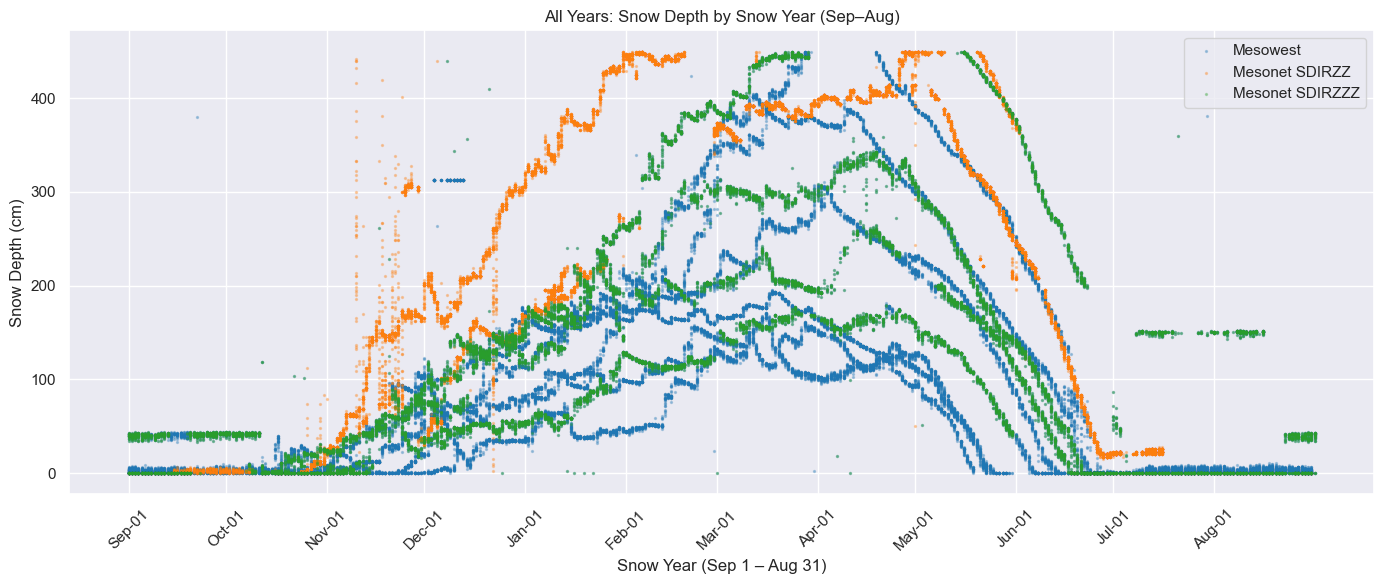

In [53]:
# Make sure your index is a DatetimeIndex
# df = df_snow_clean.copy()
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# Create a custom "snow year" day label (starting Sep 1)
def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

# Also create a label for plotting (e.g., "Sep-01", "Jan-15", etc.)
df['snow_year_day'] = df.index.map(get_snow_year_day)
df['month_day'] = df.index.strftime('%b-%d')

# Plot
plt.figure(figsize=(14, 6))

for col, label, color in [
    ('mesowest_sd1', 'Mesowest', 'tab:blue'),
    ('mesonet_sd1', 'Mesonet SDIRZZ', 'tab:orange'),
    ('mesonet_sd2', 'Mesonet SDIRZZZ', 'tab:green')
]:
    if col in df.columns:
        series = df[[col, 'snow_year_day']].dropna()
        plt.scatter(
            series['snow_year_day'],
            series[col],
            s=2, alpha=0.3,
            label=label, color=color
        )

# Set custom x-ticks (every month)
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)

plt.xlabel('Snow Year (Sep 1 – Aug 31)')
plt.ylabel('Snow Depth (cm)')
plt.title('All Years: Snow Depth by Snow Year (Sep–Aug)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Okay, that looks great... the issue with this is that we are not providing a legend with the water year assosiated with year plot... let's fix that. 

A water year starts on October 1 and ends on September 30 of the next year. So:

For any date in October–December, water_year = year + 1

For any date in January–September, water_year = year

In [54]:
df = df_snow_clean.copy()

# Remove timezone if needed
df.index = df.index.tz_convert(None)

# Assign water year
df['water_year'] = df.index.map(lambda d: d.year + 1 if d.month >= 10 else d.year)

In [55]:
def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

df['snow_year_day'] = df.index.map(get_snow_year_day)

In [59]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

/tmp/ipykernel_3357678/3687862713.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(water_years))


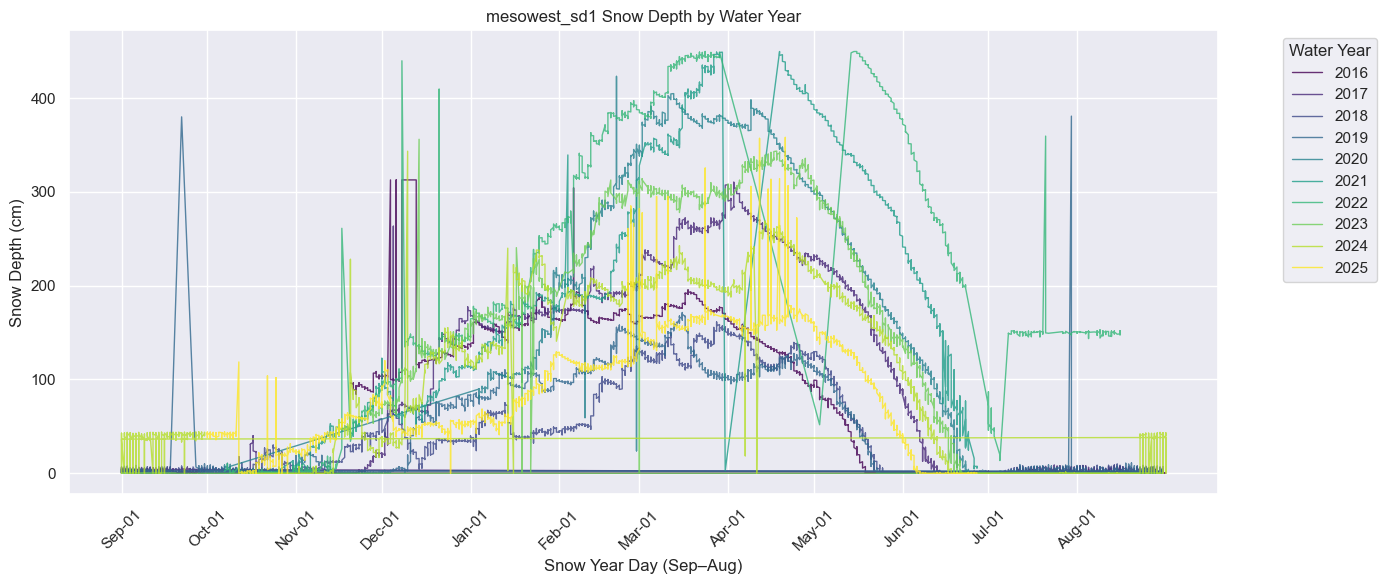

In [60]:
# Choose snow depth column to plot
depth_col = 'mesowest_sd1'  # or 'mesonet_sd1', etc.

# Drop NaN values for that column
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Set up unique years and colors
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = cm.get_cmap('viridis', len(water_years))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)  # for legend

# Create plot
plt.figure(figsize=(14, 6))

for i, year in enumerate(water_years):
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.plot(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.8,
        linewidth=1
    )

# Customize x-axis ticks (same as before)
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)

plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)

# Legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

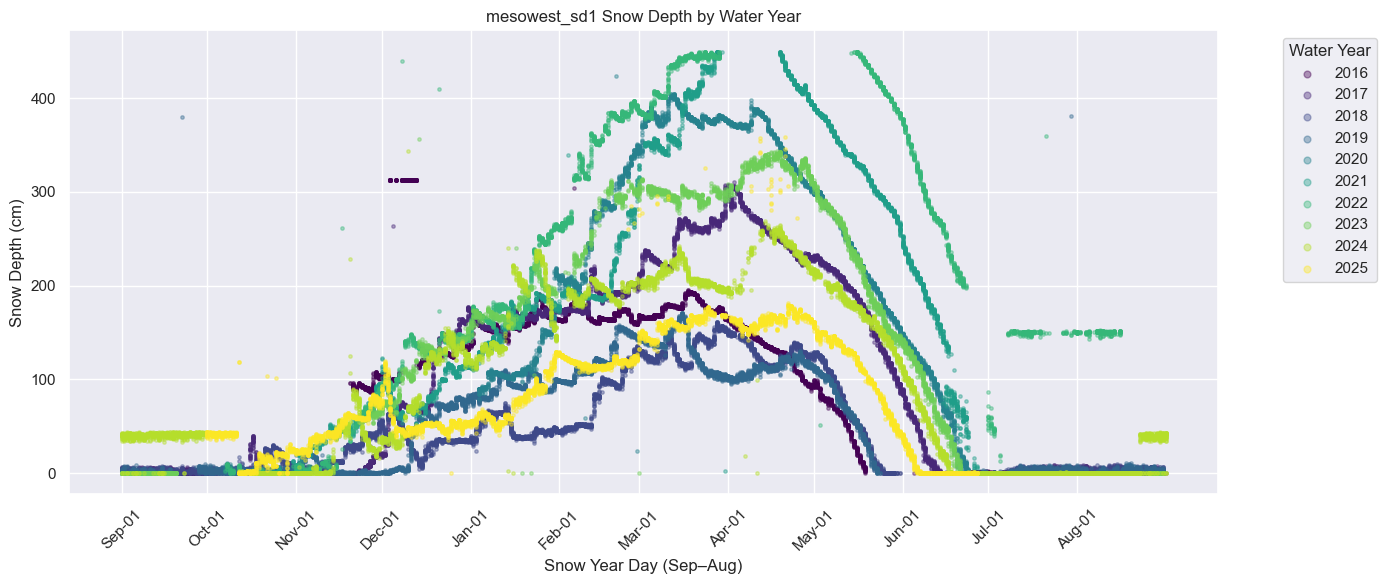

In [64]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# import matplotlib.colormaps as colormaps  # New-style access
import matplotlib

# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

add a black trend line... 

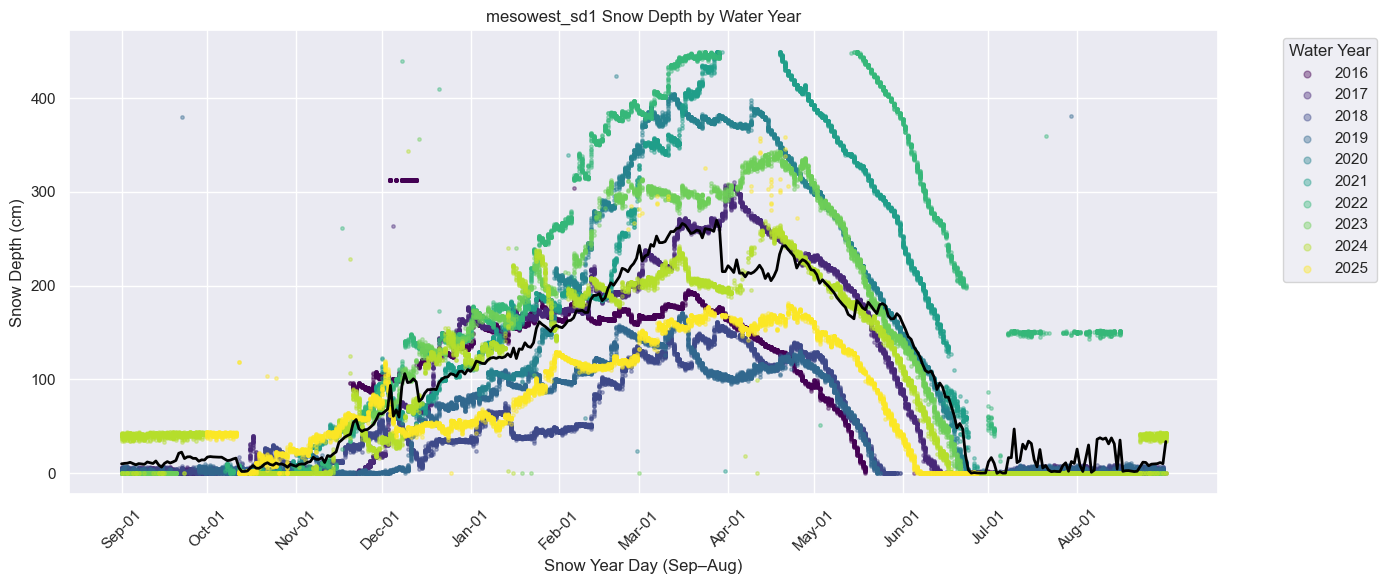

In [65]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

plt.show()

Add a label to the line, and a confidence interval 

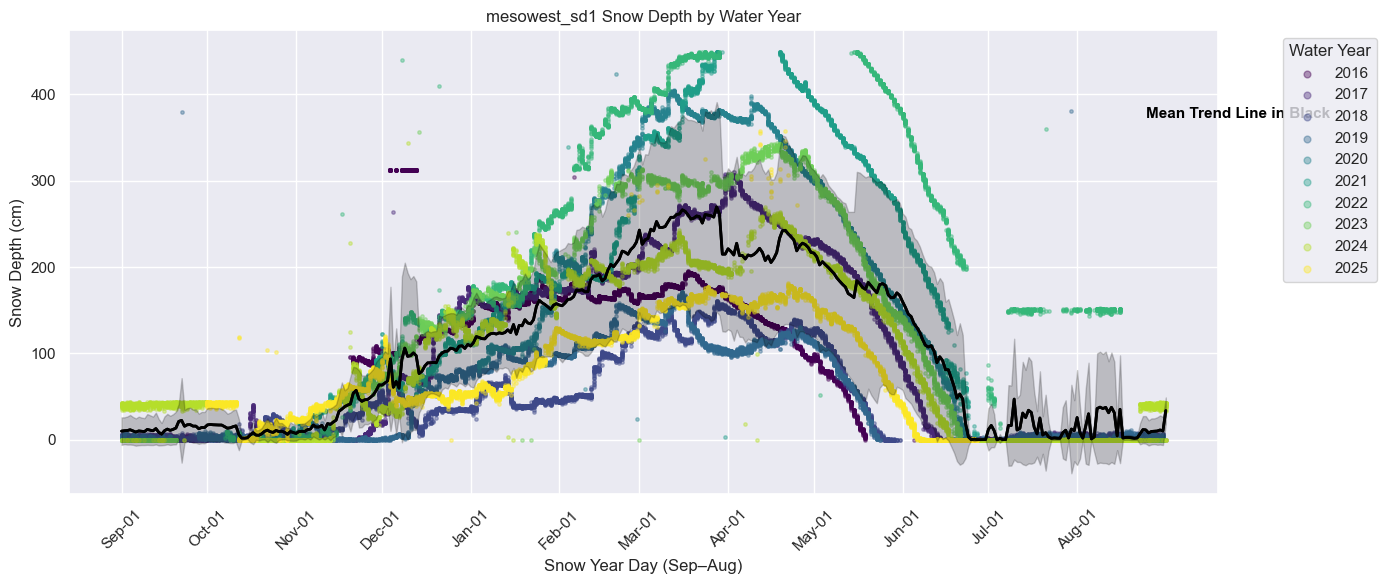

In [69]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# --- Calculate mean and std by snow_year_day ---
grouped = df_plot.groupby('snow_year_day')[depth_col]
mean_by_day = grouped.mean()
std_by_day = grouped.std()

# Plot shaded confidence interval (mean ± 1 std)
plt.fill_between(
    mean_by_day.index,
    mean_by_day - std_by_day,
    mean_by_day + std_by_day,
    color='black',
    alpha=0.2,
    label='±1 Std Dev'
)

# Plot average trend line
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# Label the line near the seasonal peak (customize as needed)
peak_day = mean_by_day.idxmax()
peak_value = mean_by_day.max()

plt.text(
    x=peak_day + 150,  # shift right or left
    y=peak_value + 100, # shift up or down
    s='Mean Trend Line in Black',
    fontsize=11,
    color='black',
    fontweight='bold',
    va='bottom',
    ha='left'
)

plt.show()

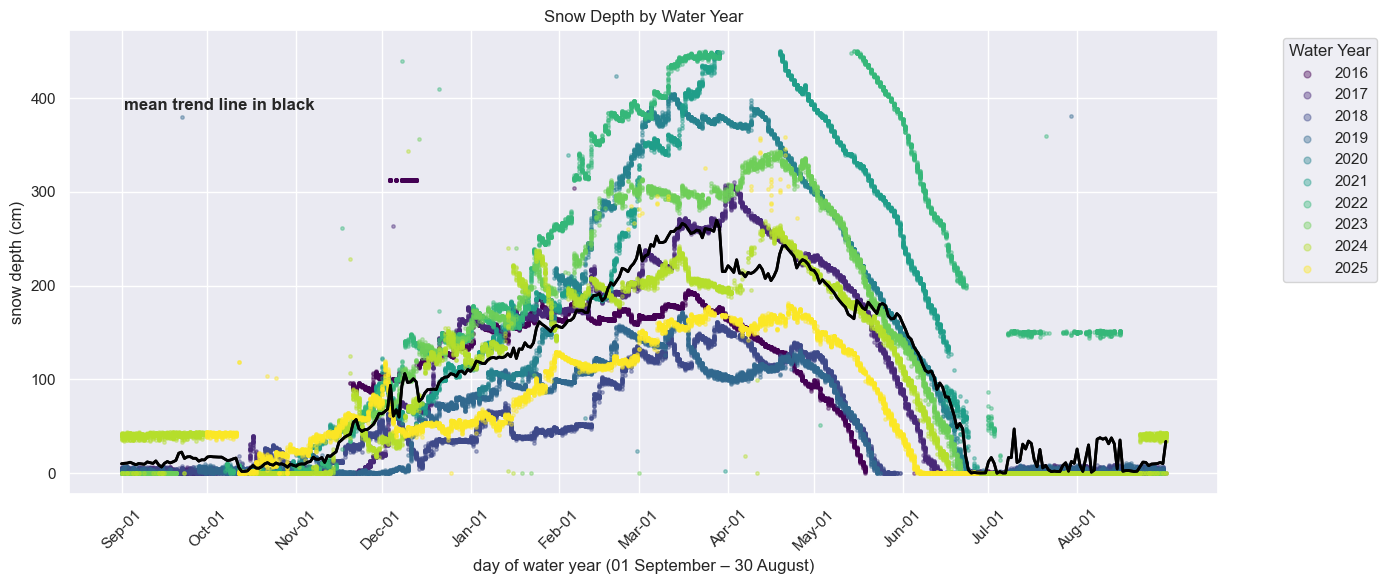

In [72]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('day of water year (01 September – 30 August)')
plt.ylabel('snow depth (cm)')
plt.title('Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# # --- Calculate mean and std by snow_year_day ---
# grouped = df_plot.groupby('snow_year_day')[depth_col]
# mean_by_day = grouped.mean()
# std_by_day = grouped.std()

# # Plot shaded confidence interval (mean ± 1 std)
# plt.fill_between(
#     mean_by_day.index,
#     mean_by_day - std_by_day,
#     mean_by_day + std_by_day,
#     color='black',
#     alpha=0.2,
#     label='±1 Std Dev'
# )

# Plot average trend line
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# # Label the line near the seasonal peak (customize as needed)
# peak_day = mean_by_day.idxmax()
# peak_value = mean_by_day.max()

# plt.text(
#     x=peak_day + 150,  # shift right or left
#     y=peak_value + 100, # shift up or down
#     s='Mean Trend Line in Black',
#     fontsize=11,
#     color='black',
#     fontweight='bold',
#     va='bottom',
#     ha='left'
# )

# add simple text in the upper right of the plot 
plt.text(x=1, y=400, s='mean trend line in black', fontweight='bold', va='top', ha='left')

plt.show()

Make this figure with `df_snow_clean_smoothed`, need to make the water year thing first,

In [77]:
import statsmodels.api as sm
# Set smoothing parameter
frac = 0.01  # Adjust this for more/less smoothing

# Reset index to access 'datetime' as a column
df_snow_clean_smoothed = df_snow_clean.reset_index()

# Apply LOWESS smoothing to all numeric columns
for col in ["mesonet_sd1", "mesonet_sd2", "mesowest_sd1"]:
    df_snow_clean_smoothed[col] = sm.nonparametric.lowess(
        df_snow_clean_smoothed[col], df_snow_clean_smoothed["datetime"], frac=frac, return_sorted=False
    )

# Restore datetime as index
df_snow_clean_smoothed.set_index("datetime", inplace=True)

In [78]:
df = df_snow_clean_smoothed.copy()

# Remove timezone if needed
df.index = df.index.tz_convert(None)

# Assign water year
df['water_year'] = df.index.map(lambda d: d.year + 1 if d.month >= 10 else d.year)

def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

df['snow_year_day'] = df.index.map(get_snow_year_day)

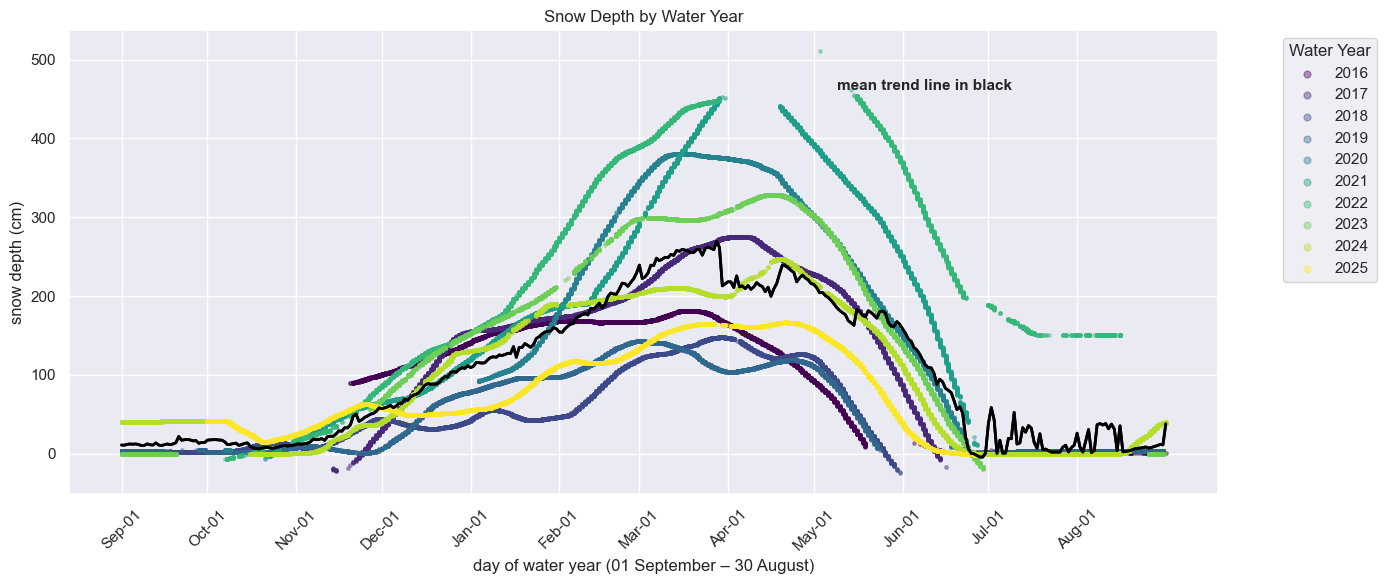

In [ ]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('day of water year (01 September – 30 August)')
plt.ylabel('snow depth (cm)')
plt.title('Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# Plot average trend line
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# add simple text in the upper right of the plot 
plt.text(x=300, y=475, s='mean trend line in black', fontsize=11, fontweight='bold', va='top', ha='left')

plt.show()

Okay, that looks weird... 

need to come back to the smoothing, but here is an example of how Jason has used it, 

In [81]:
df

,mesonet_sd1,mesonet_sd2,mesowest_sd1,datetime
2010-12-15 22:00:00+00:00,88.9,NaN,NaN,2010-12-15 22:00:00+00:00
2011-01-09 04:15:00+00:00,139.7,NaN,NaN,2011-01-09 04:15:00+00:00
2011-05-21 03:45:00+00:00,228.6,NaN,NaN,2011-05-21 03:45:00+00:00
2011-05-21 04:15:00+00:00,228.6,NaN,NaN,2011-05-21 04:15:00+00:00
2011-05-21 04:45:00+00:00,228.6,NaN,NaN,2011-05-21 04:45:00+00:00
...,...,...,...,...
2025-06-27 08:00:00+00:00,NaN,NaN,0.381,2025-06-27 08:00:00+00:00
2025-06-27 09:00:00+00:00,NaN,NaN,0.000,2025-06-27 09:00:00+00:00
2025-06-27 10:00:00+00:00,NaN,NaN,0.000,2025-06-27 10:00:00+00:00
2025-06-27 11:00:00+00:00,NaN,NaN,0.000,2025-06-27 11:00:00+00:00


In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# df = df_snow_clean.copy()
timespan = df.iloc[-1].doy - df.iloc[0].doy
 
df_smooth = lowess(df.northing, df.doy, frac=1/timespan, it=1, delta=0.1, return_sorted=False)

AttributeError: 'Series' object has no attribute 'doy'

Done for now, come back to this to fix later.

### Previous attempt at smoothing... using the code above instead, but come back if I need this. 

In [ ]:
# from statsmodels.nonparametric.smoothers_lowess import lowess

In [ ]:
# def smooth_loess(series, frac=0.05):
#     """
#     Smooth a time series using LOESS (LOWESS).
#     Args:
#         series: pandas Series with datetime index.
#         frac: Smoothing span (fraction of data to use in each local fit).
#     Returns:
#         Smoothed pandas Series with same index.
#     """
#     if series.isna().all():
#         return series.copy()  # Avoid crashing on all-NaN input

#     # Drop NaNs for fitting
#     valid = series.dropna()
#     x = valid.index.astype(np.int64)  # convert datetime to int for LOWESS
#     y = valid.values

#     smoothed = lowess(endog=y, exog=x, frac=frac, return_sorted=False)

#     # Return a full Series with NaNs where data was missing
#     smooth_series = pd.Series(index=series.index, dtype='float64')
#     smooth_series[valid.index] = smoothed
#     return smooth_series

In [38]:
# df_snow_loess = df_snow_clean.copy()

# for col in ['mesonet_SDIRZZ', 'mesonet_SDIRZZZ', 'mesowest_snow_depth_set_1']:
#     if col in df_snow_loess.columns:
#         df_snow_loess[col] = smooth_loess(df_snow_clean[col], frac=0.05)